Title: capacity_data_all_plot.ipynb

Purpose: Plot the processed capacity data

Author: Onno Nennecke on 15.02.2025 Modified: 10.09.2025

Input data: 

- Installed capacity grids: wind_offshore_ic.nc, wind_onshore_ic.nc, solar_ic_netto.nc
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/
- Wind hub height grids: wind_offshore_height_weighted.nc, wind_onshore_height_weighted.nc
    - These files lie here: /climca/people/onennecke/Wind_Solar_MaStR/processed_data/ 
- Regridded population data: population_regrid_weights.nc
    - This file lies here: /climca/people/onennecke/population_data/

Output data:

- Installed_capacity plot (+ Installed_capacity_Solar_Brutto plot)
    - These files lie here: /home/onennecke/Code/Figures/
- Hub_height_map plot
    - These files lie here: /home/onennecke/Code/Figures/

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mticker


In [2]:
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')
# grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')

In [3]:
grid_offshore_sum = grid_offshore['wind_off_cap'].sum() / 1000000
grid_onshore_sum = grid_onshore['wind_on_cap'].sum() / 1000000
grid_solar_sum = grid_solar['solar_cap'].sum() / 1000000

In [4]:
lon_edges = grid_offshore.lon.values
lat_edges = grid_offshore.lat.values
# lat_edges = np.insert(lat_edges, 0, 46)


# Convert to MW
xxx1 = grid_onshore['wind_on_cap'] / 1000000
xxx2 = grid_offshore['wind_off_cap'] / 1000000
xxx3 = grid_solar['solar_cap'] / 1000000

# Determine the common colorbar range
vmin = 0 # min(xxx1.min(), xxx2.min(), xxx3.min())
vmax = max(xxx1.max(), xxx2.max(), xxx3.max())


In [5]:
def setup_gridlines(ax, deg=2, alpha=0, ll=True):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    # make sure ticks line up with gridlines:
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=10)
    
def setup_gridlines_small(ax, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 16):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    # ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    # ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=18)

/tmp/ipykernel_1128099/1380624009.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


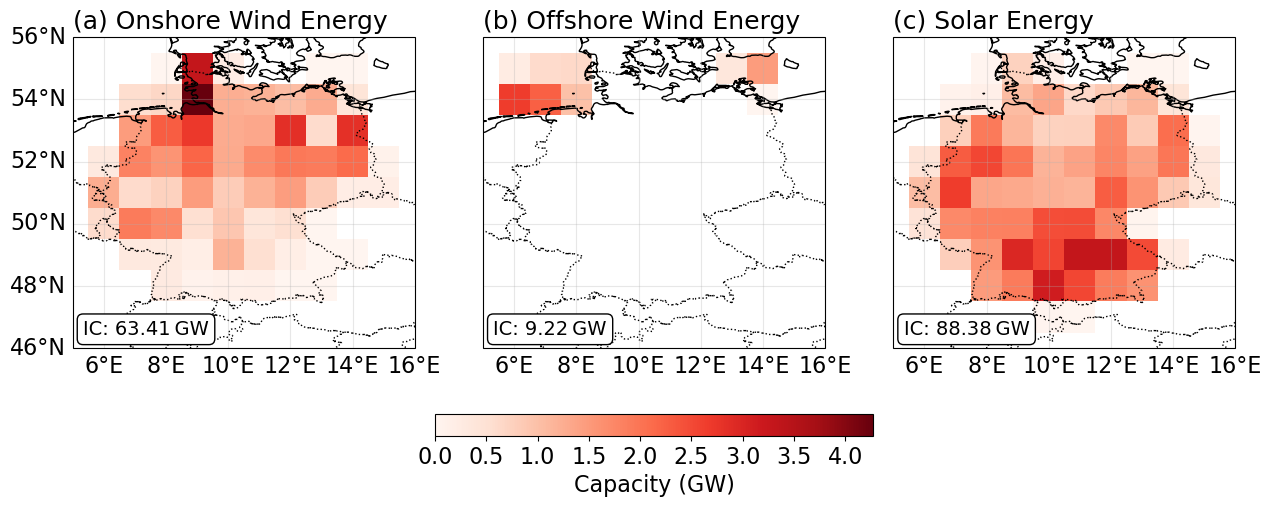

In [6]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

lon_min, lon_max = lon_edges.min(), lon_edges.max()
lat_min, lat_max = lat_edges.min(), lat_edges.max()

# create the 3-panel figure and leave room at bottom for the shared cbar
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'bottom': 0.15}  # leave 15% at the bottom for colorbar
)

axes = [ax1, ax2, ax3]
data = [xxx1, xxx2, xxx3]
labels = ['(a) Onshore Wind Energy', '(b) Offshore Wind Energy', '(c) Solar Energy']
capacities = [
    f"IC: {grid_onshore_sum.values:.2f} GW",
    f"IC: {grid_offshore_sum.values:.2f} GW",
    f"IC: {grid_solar_sum.values:.2f} GW",
]
label_sizes = {'title': 18, 'box': 14}

for ax, dat, lab, cap, ll in zip(axes, data, labels, capacities, [True, False, False]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )
    
    ax.set_extent([lon_min-1, lon_max+1.001, lat_min - 1.001, lat_max+1.001], crs=ccrs.PlateCarree())

    setup_gridlines_small(ax, deg=2, alpha=0.3, ll=ll)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed capacity text in lower right (axes coords)
    ax.text(
        0.03, 0.03, cap,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.15        # space between panels and colorbar
)
cbar.set_label('Capacity (GW)')
cbar.ax.tick_params()
# Explicit ticks from 0.0 to 4.0 every 0.5
ticks = np.arange(0.0, 4.0 + 0.5, 0.5)   # array([0. , 0.5, 1. , ..., 4. ])
cbar.set_ticks(ticks)

# Force one decimal place on tick labels
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))

plt.tight_layout()
# save the plot
plt.savefig('/home/onennecke/Code/Figures/Installed_capacity.png', dpi=600, bbox_inches='tight')
plt.show()

### Old without gridlines

/tmp/ipykernel_2161259/605399932.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


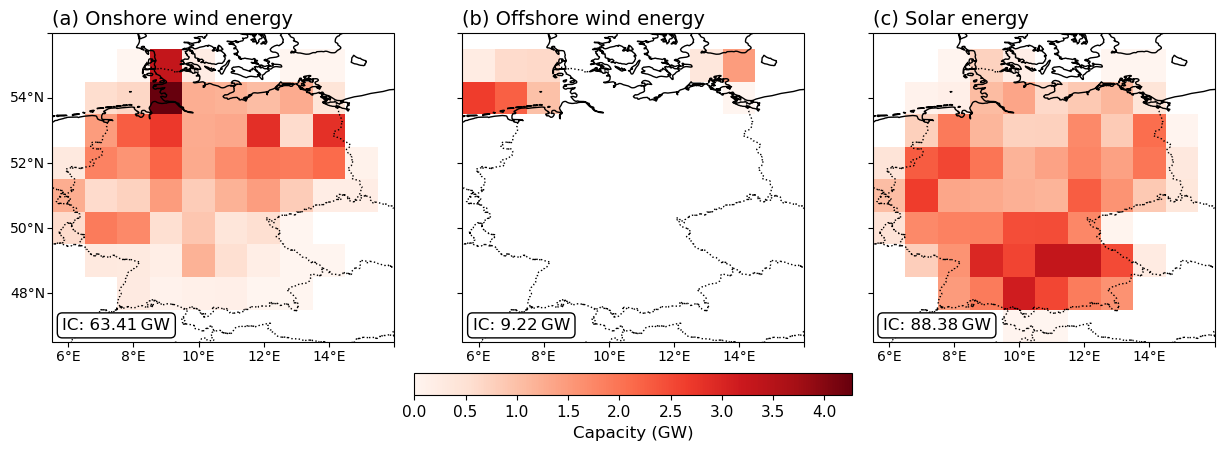

In [8]:
# create the 3-panel figure and leave room at bottom for the shared cbar
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'bottom': 0.15}  # leave 15% at the bottom for colorbar
)

axes = [ax1, ax2, ax3]
data = [xxx1, xxx2, xxx3]
labels = ['(a) Onshore wind energy', '(b) Offshore wind energy', '(c) Solar energy']
capacities = [
    f"IC: {grid_onshore_sum.values:.2f} GW",
    f"IC: {grid_offshore_sum.values:.2f} GW",
    f"IC: {grid_solar_sum.values:.2f} GW",
]
label_sizes = {'title': 14, 'box': 12}

for ax, dat, lab, cap, ll in zip(axes, data, labels, capacities, [True, False, False]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )

    setup_gridlines(ax, deg=2, alpha=0, ll=ll)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed capacity text in lower right (axes coords)
    ax.text(
        0.03, 0.03, cap,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.07        # space between panels and colorbar
)
cbar.set_label('Capacity (GW)', fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
# save the plot
plt.savefig('/home/onennecke/Code/Figures/Installed_capacity.png', dpi=600, bbox_inches='tight')
plt.show()

### Old with Bruttleistung

/tmp/ipykernel_1046031/1175440253.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


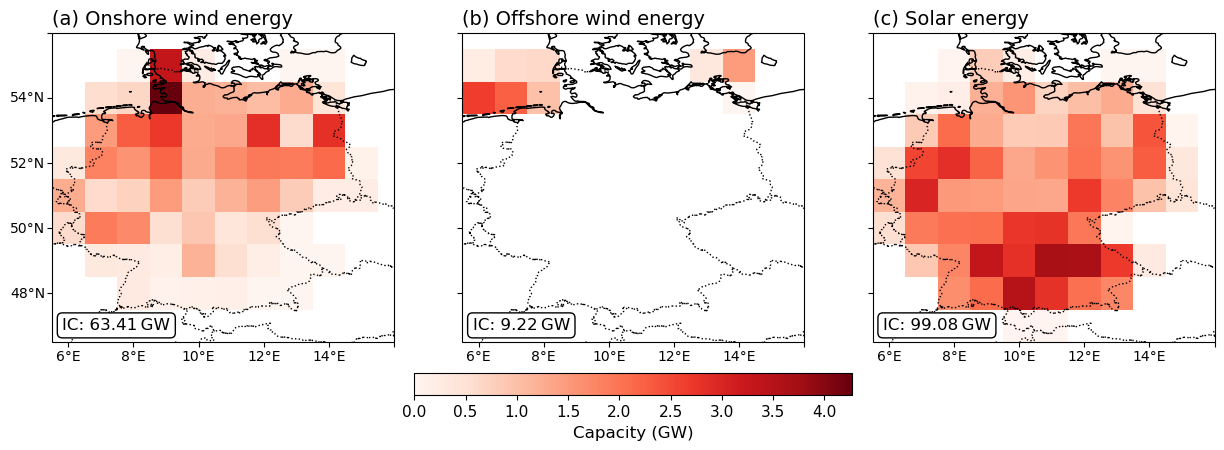

In [ ]:
# create the 3-panel figure and leave room at bottom for the shared cbar
fig, (ax1, ax2, ax3) = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 6),
    subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'bottom': 0.15}  # leave 15% at the bottom for colorbar
)

axes = [ax1, ax2, ax3]
data = [xxx1, xxx2, xxx3]
labels = ['(a) Onshore wind energy', '(b) Offshore wind energy', '(c) Solar energy']
capacities = [
    f"IC: {grid_onshore_sum.values:.2f} GW",
    f"IC: {grid_offshore_sum.values:.2f} GW",
    f"IC: {grid_solar_sum.values:.2f} GW",
]
label_sizes = {'title': 14, 'box': 12}

for ax, dat, lab, cap, ll in zip(axes, data, labels, capacities, [True, False, False]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )

    setup_gridlines(ax, deg=2, alpha=0, ll=ll)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed capacity text in lower right (axes coords)
    ax.text(
        0.03, 0.03, cap,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.07        # space between panels and colorbar
)
cbar.set_label('Capacity (GW)', fontsize=12)
cbar.ax.tick_params(labelsize=11)

plt.tight_layout()
# save the plot
# plt.savefig('/home/onennecke/Code/Figures/Installed_capacity_Solar_Brutto.png', dpi=600, bbox_inches='tight')
plt.show()

---

### Weighted Hub height Map

In [7]:
# Open height datasets

grid_offshore_weighted = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')
grid_onshore_weighted = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
#rename data variable
grid_offshore_weighted = grid_offshore_weighted.rename_vars({'wind_off_hub_height': 'wind_off_hub_height_weighted'})
grid_onshore_weighted = grid_onshore_weighted.rename_vars({'wind_on_hub_height': 'wind_on_hub_height_weighted'})

In [8]:
lon_edges = grid_offshore_weighted.lon.values # - (grid_offshore_weighted.lon.diff(dim='lon') / 2).pad({'lon': (1, 0)}, mode='edge')
lat_edges = grid_offshore_weighted.lat.values # - (grid_offshore_weighted.lat.diff(dim='lat') / 2).pad({'lat': (1, 0)}, mode='edge')

xxx1 = grid_onshore_weighted['wind_on_hub_height_weighted']
xxx2 = grid_offshore_weighted['wind_off_hub_height_weighted']

# Determine the common colorbar range
vmin = min(xxx1.min(), xxx2.min())
vmax = max(xxx1.max(), xxx2.max())


In [9]:
min(xxx1.min(), xxx2.min())

<xarray.DataArray 'wind_on_hub_height_weighted' ()> Size: 8B
array(34.75)
Coordinates:
    crs       int64 8B ...
    gridtype  <U6 24B ...

In [10]:
print('Onshore: \n', pd.Series(xxx1.values.flatten()).describe())
print('Offshore: \n', pd.Series(xxx2.values.flatten()).describe())

Onshore: 
 count     63.000000
mean     104.359535
std       23.066340
min       34.750000
25%       96.645419
50%      105.180169
75%      122.229592
max      141.760178
dtype: float64
Offshore: 
 count      9.000000
mean      95.259944
std        8.566256
min       76.700599
25%       91.913408
50%       96.008528
75%      102.000000
max      103.761859
dtype: float64


/tmp/ipykernel_1128099/307944470.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


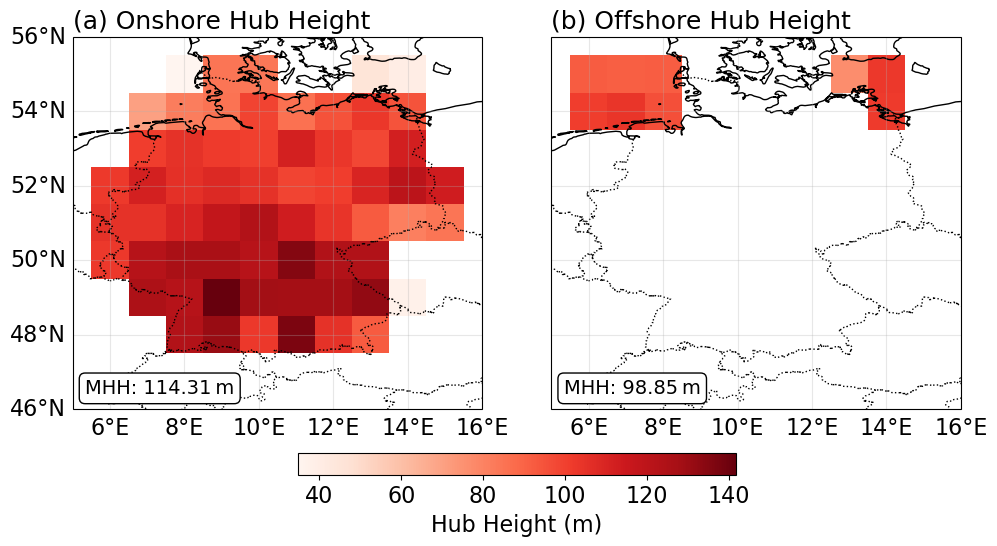

In [11]:
mpl.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
    'figure.titlesize': 18,
})

lon_min, lon_max = lon_edges.min(), lon_edges.max()
lat_min, lat_max = lat_edges.min(), lat_edges.max()


# Plot the data with common colorbar range
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'bottom': 0.15, 'wspace': -0.3}  # leave 15% at the bottom for colorbar
)

axes = [ax1, ax2]
data = [xxx1, xxx2]
labels = ['(a) Onshore Hub Height', '(b) Offshore Hub Height']
hub_heights = [
    f"MHH: 114.31 m", #{grid_onshore_sum.values:.2f}
    f"MHH: 98.85 m", #{grid_offshore_sum.values:.2f}
]
label_sizes = {'title': 18, 'box': 14}


for ax, dat, lab, hh, ll in zip(axes, data, labels, hub_heights, [True, False]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )

    ax.set_extent([lon_min-1, lon_max+1.001, lat_min - 1.001, lat_max+1.001], crs=ccrs.PlateCarree())

    setup_gridlines_small(ax, deg=2, alpha=0.3, ll=ll)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed hub_heights text in lower right (axes coords)
    ax.text(
        0.03, 0.03, hh,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.1        # space between panels and colorbar
)
cbar.set_label('Hub Height (m)')
cbar.ax.tick_params()
plt.tight_layout()

plt.savefig('/home/onennecke/Code/Figures/Hub_height_map.png', dpi=300, bbox_inches='tight')

plt.show()

/tmp/ipykernel_1046031/1142156749.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


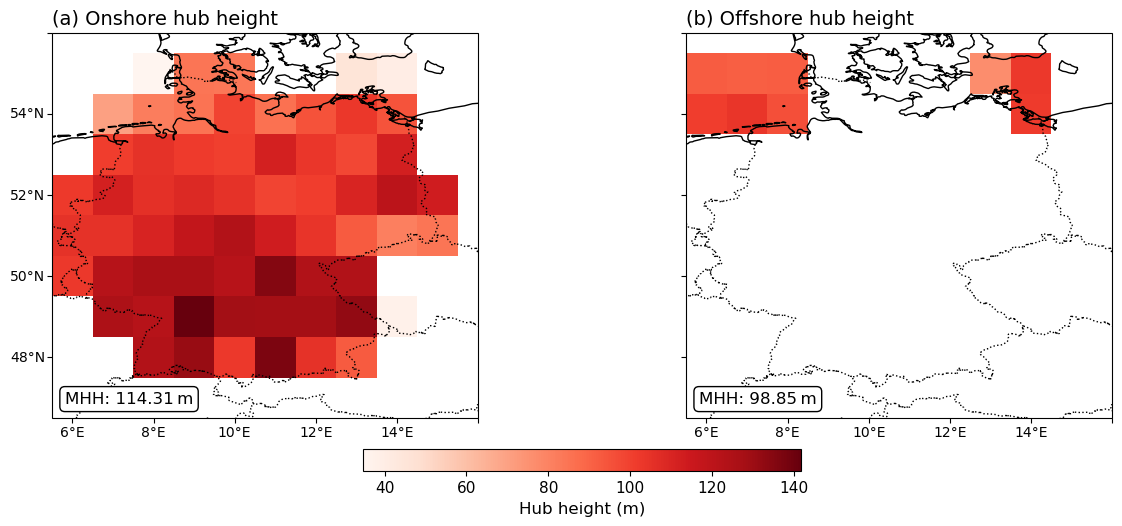

In [ ]:
# Plot the data with common colorbar range
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()},
    gridspec_kw={'bottom': 0.15}  # leave 15% at the bottom for colorbar
)

axes = [ax1, ax2]
data = [xxx1, xxx2]
labels = ['(a) Onshore hub height', '(b) Offshore hub height']
hub_heights = [
    f"MHH: 114.31 m", #{grid_onshore_sum.values:.2f}
    f"MHH: 98.85 m", #{grid_offshore_sum.values:.2f}
]
label_sizes = {'title': 14, 'box': 12}




for ax, dat, lab, hh, ll in zip(axes, data, labels, hub_heights, [True, False]):
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')

    im = ax.pcolormesh(
        lon_edges, lat_edges, dat,
        transform=ccrs.PlateCarree(),
        cmap='Reds', vmin=vmin, vmax=vmax
    )

    setup_gridlines(ax, deg=2, alpha=0, ll=ll)

    # Left‑aligned title
    ax.set_title(lab, loc='left', fontsize=label_sizes['title'])

    # Boxed hub_heights text in lower right (axes coords)
    ax.text(
        0.03, 0.03, hh,
        transform=ax.transAxes,
        ha='left', va='bottom',
        fontsize=label_sizes['box'],
        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3')
    )

# Single shared colorbar below all panels
cbar = fig.colorbar(
    im, ax=axes, orientation='horizontal',
    fraction=0.05,  # height of colorbar
    pad=0.07        # space between panels and colorbar
)
cbar.set_label('Hub height (m)', fontsize=12)
cbar.ax.tick_params(labelsize=11)
plt.tight_layout()

plt.savefig('/home/onennecke/Code/Figures/Hub_height_map.png', dpi=300, bbox_inches='tight')

plt.show()

----

In [12]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
mask_offshore = xr.where(np.isfinite(grid_offshore), 1, 0)
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
mask_onshore = xr.where(np.isfinite(grid_onshore), 1, 0)
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic_netto.nc')
grid_solar = grid_solar['solar_cap']
mask_solar = xr.where(np.isfinite(grid_solar), 1, 0)
population = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')
population = population['population']
mask_population = xr.where(np.isfinite(population), 1, 0)

In [13]:
# Overall mask
overall_mask = mask_offshore + mask_onshore + mask_solar + mask_population
overall_mask = xr.where(overall_mask > 0, 1, 0)
# mask

In [14]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    
# Define a rough area for Germany
n = 55.5
s = 47
w = 5.5
e = 15.5

lon_edges = mask_offshore['lon'].values
lat_edges = mask_offshore['lat'].values

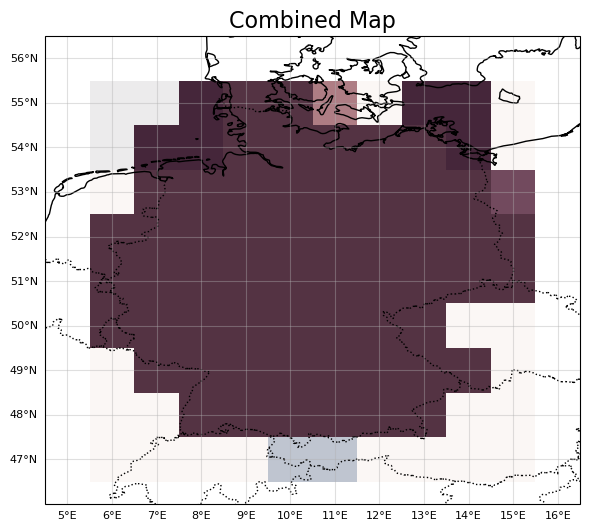

In [12]:
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': ccrs.PlateCarree()})

# Set map extent
ax.set_extent([w-1, e+1, s-1, n+1], crs=ccrs.PlateCarree())
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.set_title('Combined Map', fontsize=16)

# Plot each layer with some transparency
im1 = ax.pcolormesh(lon_edges, lat_edges, mask_offshore, transform=ccrs.PlateCarree(), cmap='Blues', alpha=0.5)
im2 = ax.pcolormesh(lon_edges, lat_edges, mask_onshore, transform=ccrs.PlateCarree(), cmap='Greens', alpha=0.5)
im3 = ax.pcolormesh(lon_edges, lat_edges, mask_solar, transform=ccrs.PlateCarree(), cmap='Blues', alpha=0.5)
im4 = ax.pcolormesh(lon_edges, lat_edges, mask_population, transform=ccrs.PlateCarree(), cmap='Reds', alpha=0.5)

# Add gridlines
setup_gridlines(ax)

plt.tight_layout()
plt.show()

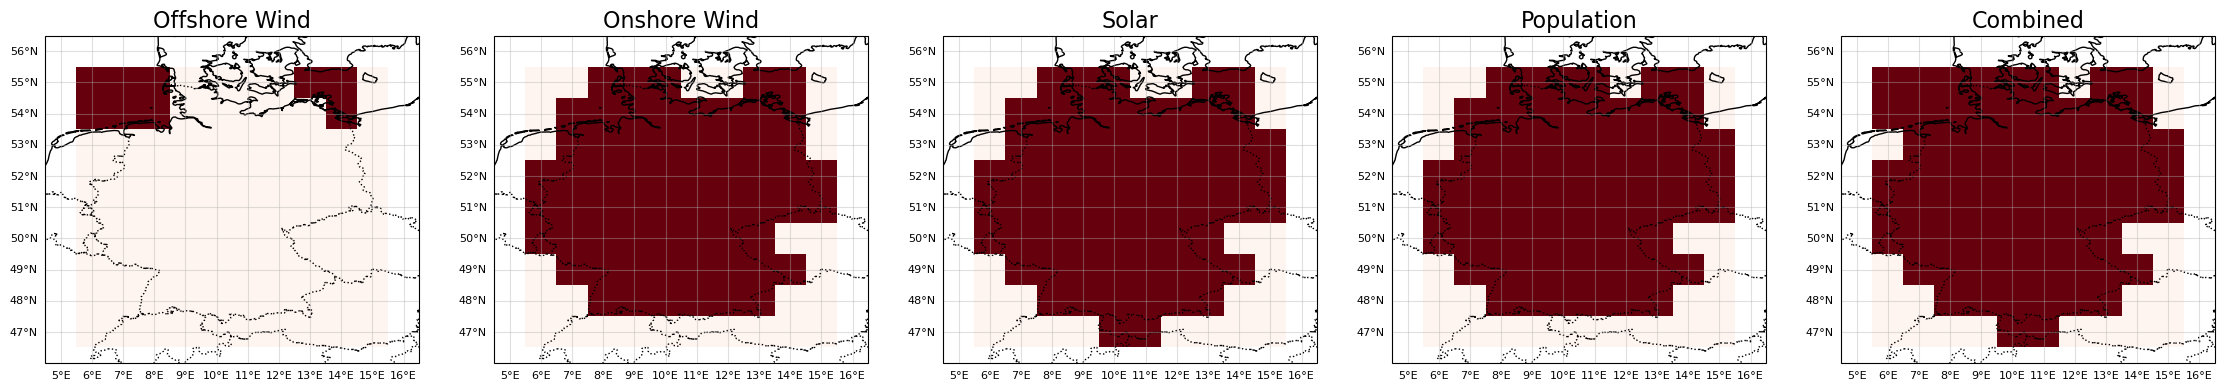

In [13]:
fig, axs = plt.subplots(1,5, figsize=(28, 8), subplot_kw={'projection': ccrs.PlateCarree()})
masks = [mask_offshore, mask_onshore, mask_solar, mask_population, overall_mask]
titles = ['Offshore Wind', 'Onshore Wind', 'Solar', 'Population', 'Combined']
for ax, m, titles in zip(axs.flat, masks, titles):
    ax.set_extent([w-1, e+1, s-1, n+1], crs=ccrs.PlateCarree()) #[5, 16, 47, 56]
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
    ax.set_title(f'{titles}', fontsize=16)
    
    # Plot the data
    im = ax.pcolormesh(lon_edges, lat_edges, m, transform=ccrs.PlateCarree(), cmap='Reds')
    
    # Add gridlines and colorbar
    setup_gridlines(ax)
    # cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

plt.show()